# Day 1: 데이터 수집 및 정제

## 프로젝트 개요
국내 주요 종목(삼성전자, KOSPI)의 주가에 영향을 미치는 외부 요인(환율, 금리, 유가 등)을 분석하기 위한 데이터 수집 및 정제 파이프라인

## 수집 대상
| 변수 | 티커/소스 | 설명 |
|------|-----------|------|
| 삼성전자 주가 | 005930.KS | KRX 상장 주식 |
| KOSPI 지수 | ^KS11 | 한국 종합 주가지수 |
| SK하이닉스 | 000660.KS | 반도체 섹터 비교 |
| NAVER | 035420.KS | IT 섹터 비교 |
| USD/KRW 환율 | KRW=X | 달러-원 환율 |
| WTI 유가 | CL=F | 원유 선물 |
| 미국 10년물 국채금리 | ^TNX | 글로벌 금리 지표 |
| S&P 500 | ^GSPC | 미국 증시 동향 |
| NASDAQ | ^IXIC | 기술주 지수 |
| 금 | GC=F | 안전자산 |

## 분석 기간
- **전체 기간**: 2020-01-01 ~ 2024-12-31 (5년, COVID 이후 포함)
- **이벤트 기간**: COVID 쇼크(2020.03), 금리인상 사이클(2022), 반도체 슈퍼사이클(2023~2024)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
import json
from datetime import datetime

# 한글 폰트 설정
import matplotlib.font_manager as fm
import platform

if platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Linux':
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 경로 설정
PROJECT_ROOT = Path('..').resolve()
RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DATA_DIR = PROJECT_ROOT / 'data' / 'processed'

print(f'프로젝트 루트: {PROJECT_ROOT}')
print(f'원본 데이터 경로: {RAW_DATA_DIR}')

프로젝트 루트: /Users/jin/korean-stock-external-factors-eda
원본 데이터 경로: /Users/jin/korean-stock-external-factors-eda/data/raw


## 1. 데이터 수집 파이프라인

In [2]:
# ── 수집 대상 정의 ──────────────────────────────────────────────
TICKERS = {
    # 한국 주식
    'samsung':   '005930.KS',
    'skhynix':   '000660.KS',
    'naver':     '035420.KS',
    # 국내 지수
    'kospi':     '^KS11',
    # 외환
    'usdkrw':    'KRW=X',
    # 원자재
    'wti':       'CL=F',
    'gold':      'GC=F',
    # 금리
    'us10y':     '^TNX',
    # 해외 지수
    'sp500':     '^GSPC',
    'nasdaq':    '^IXIC',
}

START_DATE = '2020-01-01'
END_DATE   = '2024-12-31'

print(f'수집 종목 수: {len(TICKERS)}')
print(f'수집 기간: {START_DATE} ~ {END_DATE}')

수집 종목 수: 10
수집 기간: 2020-01-01 ~ 2024-12-31


In [3]:
def fetch_price_data(tickers: dict, start: str, end: str) -> dict[str, pd.DataFrame]:
    """
    yfinance로 종목별 OHLCV 데이터를 수집한다.
    
    Parameters
    ----------
    tickers : dict  {label: yf_ticker}
    start   : str   'YYYY-MM-DD'
    end     : str   'YYYY-MM-DD'
    
    Returns
    -------
    dict {label: DataFrame}  — 수집 성공 종목만 포함
    """
    result = {}
    failed = []

    for label, ticker in tickers.items():
        try:
            df = yf.download(ticker, start=start, end=end,
                             auto_adjust=True, progress=False)
            if df.empty:
                print(f'  [WARN] {label}({ticker}): 데이터 없음')
                failed.append(label)
                continue

            # MultiIndex 컬럼 평탄화 (yfinance >= 0.2 대응)
            if isinstance(df.columns, pd.MultiIndex):
                df.columns = df.columns.get_level_values(0)

            df.index.name = 'Date'
            df['label'] = label
            df['ticker'] = ticker
            result[label] = df
            print(f'  [OK]   {label}({ticker}): {len(df):,}행 수집')

        except Exception as e:
            print(f'  [ERR]  {label}({ticker}): {e}')
            failed.append(label)

    print(f'\n수집 완료: {len(result)}/{len(tickers)} 성공')
    if failed:
        print(f'실패 목록: {failed}')
    return result


print('데이터 수집 시작...')
raw_data = fetch_price_data(TICKERS, START_DATE, END_DATE)

데이터 수집 시작...


  [OK]   samsung(005930.KS): 1,229행 수집


  [OK]   skhynix(000660.KS): 1,229행 수집


  [OK]   naver(035420.KS): 1,229행 수집


  [OK]   kospi(^KS11): 1,229행 수집


...

  [OK]   wti(CL=F): 1,257행 수집


  [OK]   gold(GC=F): 1,257행 수집


  [OK]   us10y(^TNX): 1,257행 수집


  [OK]   sp500(^GSPC): 1,257행 수집


  [OK]   nasdaq(^IXIC): 1,257행 수집

수집 완료: 10/10 성공


## 2. 원본 데이터 저장

In [4]:
# 원본 데이터 CSV 저장
for label, df in raw_data.items():
    path = RAW_DATA_DIR / f'{label}_raw.csv'
    df.to_csv(path)
    print(f'  저장: {path.name}')

print('\n원본 데이터 저장 완료')

  저장: samsung_raw.csv
  저장: skhynix_raw.csv
  저장: naver_raw.csv
  저장: kospi_raw.csv
  저장: usdkrw_raw.csv
  저장: wti_raw.csv
  저장: gold_raw.csv
  저장: us10y_raw.csv
  저장: sp500_raw.csv
  저장: nasdaq_raw.csv

원본 데이터 저장 완료


## 3. 데이터 품질 검사

In [5]:
def assess_data_quality(data: dict[str, pd.DataFrame]) -> pd.DataFrame:
    """
    각 종목의 데이터 품질 지표를 계산한다.
    
    반환 컬럼:
    - rows          : 전체 행 수
    - date_start    : 시작일
    - date_end      : 종료일
    - missing_close : Close 결측 수
    - missing_pct   : Close 결측률 (%)
    - zero_volume   : 거래량 0인 날 수
    - outlier_count : |수익률| > 20% 이상치 수
    - quality_score : 종합 품질 점수 (0~100)
    """
    records = []

    for label, df in data.items():
        close = df['Close']
        n = len(df)

        missing_close = close.isna().sum()
        missing_pct   = missing_close / n * 100

        zero_volume = (df['Volume'] == 0).sum() if 'Volume' in df.columns else 0

        daily_ret = close.pct_change().dropna()
        outlier_count = (daily_ret.abs() > 0.20).sum()

        # 품질 점수: 결측률·이상치 비율에 따라 차감
        score = 100
        score -= min(missing_pct * 2, 40)          # 결측률 1% → -2점, 최대 -40
        score -= min(outlier_count / n * 1000, 30) # 이상치 과다 시 -30
        score -= min(zero_volume / n * 100, 20)    # 거래량 0 과다 시 -20
        score = max(score, 0)

        records.append({
            'label':         label,
            'rows':          n,
            'date_start':    df.index.min().strftime('%Y-%m-%d'),
            'date_end':      df.index.max().strftime('%Y-%m-%d'),
            'missing_close': int(missing_close),
            'missing_pct':   round(missing_pct, 2),
            'zero_volume':   int(zero_volume),
            'outlier_count': int(outlier_count),
            'quality_score': round(score, 1),
        })

    return pd.DataFrame(records).set_index('label')


quality_report = assess_data_quality(raw_data)
display(quality_report.style
    .background_gradient(subset=['quality_score'], cmap='RdYlGn', vmin=60, vmax=100)
    .background_gradient(subset=['missing_pct'], cmap='YlOrRd', vmin=0, vmax=5)
    .format({'missing_pct': '{:.2f}%', 'quality_score': '{:.1f}'}))

,rows,date_start,date_end,missing_close,missing_pct,zero_volume,outlier_count,quality_score
label,,,,,,,,
samsung,1229,2020-01-02,2024-12-30,0,0.00%,13,0,98.9
skhynix,1229,2020-01-02,2024-12-30,0,0.00%,15,0,98.8
naver,1229,2020-01-02,2024-12-30,0,0.00%,16,0,98.7
kospi,1229,2020-01-02,2024-12-30,0,0.00%,1,0,99.9
usdkrw,1304,2020-01-01,2024-12-30,0,0.00%,1304,0,80.0
wti,1257,2020-01-02,2024-12-30,0,0.00%,1,11,91.2
gold,1257,2020-01-02,2024-12-30,0,0.00%,3,0,99.8
us10y,1257,2020-01-02,2024-12-30,0,0.00%,1257,6,75.2
sp500,1257,2020-01-02,2024-12-30,0,0.00%,1,0,99.9


## 4. 데이터 정제 파이프라인

In [6]:
def clean_price_data(df: pd.DataFrame, label: str) -> pd.DataFrame:
    """
    결측치·이상치를 처리하여 정제된 일별 종가 시계열을 반환한다.

    처리 규칙
    ----------
    1. 결측치: 전 영업일 종가로 forward-fill → 최대 5일 허용
    2. 음수 가격: 제거 (데이터 오류)
    3. 극단 이상치: |일간 수익률| > 30% → 전일 종가로 대체
       (단, 실제 서킷브레이커 등 이벤트일은 유지 — 20% 초과 건만 플래그)
    4. 거래량 0: 유지 (공휴일 데이터 미포함 확인용)
    """
    df = df.copy()
    changes_log = []

    # ── 음수 제거 ─────────────────────────────────────────────
    neg_mask = df['Close'] < 0
    if neg_mask.any():
        df.loc[neg_mask, 'Close'] = np.nan
        changes_log.append(f'음수 가격 제거: {neg_mask.sum()}건')

    # ── 결측치 보간 (ffill, 최대 5일) ────────────────────────
    missing_before = df['Close'].isna().sum()
    df['Close'] = df['Close'].ffill(limit=5)
    missing_after = df['Close'].isna().sum()
    if missing_before > 0:
        changes_log.append(f'결측치 ffill: {missing_before}건 → {missing_after}건 잔존')

    # ── 극단 이상치 플래그 및 대체 ───────────────────────────
    daily_ret = df['Close'].pct_change()
    extreme_mask = daily_ret.abs() > 0.30   # 30% 초과
    df['is_extreme'] = False

    # 20%~30% 구간: 플래그만 설정 (실제 이벤트 가능)
    flag_mask = (daily_ret.abs() > 0.20) & (daily_ret.abs() <= 0.30)
    df.loc[flag_mask, 'is_extreme'] = True

    # 30% 초과: 데이터 오류로 간주, 전일 종가로 대체
    if extreme_mask.any():
        extreme_dates = df.index[extreme_mask].tolist()
        df.loc[extreme_mask, 'Close'] = np.nan
        df['Close'] = df['Close'].ffill(limit=1)
        df.loc[extreme_mask, 'is_extreme'] = True
        changes_log.append(f'극단 이상치(>30%) 대체: {extreme_mask.sum()}건 ({[d.strftime("%Y-%m-%d") for d in extreme_dates]})')

    changes_log_str = '; '.join(changes_log) if changes_log else '변경 없음'
    print(f'  [{label}] {changes_log_str}')

    return df[['Close', 'Volume', 'is_extreme', 'label', 'ticker']]


print('데이터 정제 시작...')
cleaned_data = {label: clean_price_data(df, label) for label, df in raw_data.items()}
print('\n정제 완료')

데이터 정제 시작...
  [samsung] 변경 없음
  [skhynix] 변경 없음
  [naver] 변경 없음
  [kospi] 변경 없음
  [usdkrw] 변경 없음
  [wti] 음수 가격 제거: 1건; 결측치 ffill: 1건 → 0건 잔존; 극단 이상치(>30%) 대체: 2건 (['2020-04-21', '2020-04-22'])
  [gold] 변경 없음
  [us10y] 극단 이상치(>30%) 대체: 2건 (['2020-03-10', '2020-03-17'])
  [sp500] 변경 없음
  [nasdaq] 변경 없음

정제 완료


## 5. 통합 데이터셋 구성

In [7]:
def build_master_dataset(cleaned: dict[str, pd.DataFrame]) -> pd.DataFrame:
    """
    종목별 정제 데이터를 종가(Close) 기준 Wide 포맷으로 병합한다.
    
    - inner join: 모든 종목에 공통 거래일만 포함
    - 결측 최소화를 위해 outer join 후 비율 확인도 병행
    """
    close_dict = {label: df['Close'].rename(label) for label, df in cleaned.items()}
    master = pd.concat(close_dict.values(), axis=1)
    master.index.name = 'Date'

    # 결측 요약
    missing_summary = master.isna().sum()
    print('=== 통합 데이터셋 결측 현황 ===')
    print(missing_summary[missing_summary > 0].to_string() or '결측 없음')
    print(f'\n전체 행: {len(master):,} | 컬럼: {len(master.columns)}')

    return master


master_df = build_master_dataset(cleaned_data)
display(master_df.head())
display(master_df.tail())

=== 통합 데이터셋 결측 현황 ===
samsung    75
skhynix    75
naver      75
kospi      75
wti        48
gold       47
us10y      47
sp500      47
nasdaq     47

전체 행: 1,304 | 컬럼: 10


,samsung,skhynix,naver,kospi,usdkrw,wti,gold,us10y,sp500,nasdaq
Date,,,,,,,,,,
2020-01-01,NaN,NaN,NaN,NaN,1153.750000,NaN,NaN,NaN,NaN,NaN
2020-01-02,47470.902344,88898.828125,177355.468750,2175.169922,1153.969971,61.180000,1524.500000,1.882,3257.850098,9092.190430
2020-01-03,47728.890625,88711.093750,176383.640625,2176.459961,1157.150024,63.049999,1549.199951,1.788,3234.850098,9020.769531
2020-01-06,47728.890625,88523.335938,175411.843750,2155.070068,1165.849976,63.270000,1566.199951,1.811,3246.280029,9071.469727
2020-01-07,47986.882812,88241.703125,181728.609375,2175.540039,1167.420044,62.700001,1571.800049,1.827,3237.179932,9068.580078


,samsung,skhynix,naver,kospi,usdkrw,wti,gold,us10y,sp500,nasdaq
Date,,,,,,,,,,
2024-12-24,52890.777344,166448.171875,199416.796875,2440.520020,1442.699951,70.099998,2620.000000,4.591,6040.040039,20031.130859
2024-12-25,NaN,NaN,NaN,NaN,1453.420044,NaN,NaN,NaN,NaN,NaN
2024-12-26,52112.972656,168028.687500,196856.390625,2429.669922,1457.609985,69.620003,2638.800049,4.579,6037.589844,20020.359375
2024-12-27,52566.195312,172375.125000,194689.875000,2404.770020,1466.989990,70.599998,2617.199951,4.619,5970.839844,19722.029297
2024-12-30,52076.750000,171782.421875,195871.609375,2399.489990,1472.800049,70.989998,2606.100098,4.545,5906.939941,19486.789062


In [8]:
# 일간 수익률 데이터셋 생성
returns_df = master_df.pct_change(fill_method=None).dropna(how='all')

print('=== 일간 수익률 기초 통계 ===' )
display(returns_df.describe().round(4))

=== 일간 수익률 기초 통계 ===


,samsung,skhynix,naver,kospi,usdkrw,wti,gold,us10y,sp500,nasdaq
count,1174.0000,1174.0000,1174.0000,1174.0000,1303.0000,1208.0000,1210.0000,1210.0000,1210.0000,1210.0000
mean,0.0001,0.0004,0.0004,0.0001,0.0002,0.0011,0.0005,0.0014,0.0007,0.0008
std,0.0168,0.0246,0.0221,0.0127,0.0057,0.0319,0.0103,0.0443,0.0136,0.0161
min,-0.1030,-0.1040,-0.0893,-0.0877,-0.0344,-0.2459,-0.0498,-0.2932,-0.1198,-0.1232
25%,-0.0099,-0.0140,-0.0122,-0.0069,-0.0031,-0.0135,-0.0044,-0.0150,-0.0053,-0.0068
50%,0.0000,0.0000,0.0000,0.0006,0.0004,0.0022,0.0007,0.0004,0.0010,0.0014
75%,0.0082,0.0147,0.0111,0.0073,0.0037,0.0164,0.0062,0.0167,0.0074,0.0095
max,0.1047,0.1340,0.0994,0.0860,0.0207,0.2510,0.0595,0.7390,0.0938,0.0935


## 6. 정제 데이터 저장

In [9]:
# 통합 종가 데이터
master_path = PROCESSED_DATA_DIR / 'master_close.csv'
master_df.to_csv(master_path)
print(f'저장: {master_path}')

# 일간 수익률 데이터
returns_path = PROCESSED_DATA_DIR / 'daily_returns.csv'
returns_df.to_csv(returns_path)
print(f'저장: {returns_path}')

# 품질 리포트
quality_path = PROCESSED_DATA_DIR / 'data_quality_report.csv'
quality_report.to_csv(quality_path)
print(f'저장: {quality_path}')

저장: /Users/jin/korean-stock-external-factors-eda/data/processed/master_close.csv
저장: /Users/jin/korean-stock-external-factors-eda/data/processed/daily_returns.csv
저장: /Users/jin/korean-stock-external-factors-eda/data/processed/data_quality_report.csv


## 7. 데이터 품질 기준 문서화

In [10]:
quality_standards = {
    "version": "1.0",
    "created_at": datetime.now().strftime('%Y-%m-%d'),
    "data_scope": {
        "start_date": START_DATE,
        "end_date":   END_DATE,
        "tickers":    TICKERS,
    },
    "quality_criteria": {
        "min_rows":              "≥ 1,000 (5년치 영업일 기준 약 1,250일)",
        "max_missing_rate":      "Close 기준 5% 이하",
        "outlier_treatment":     "|일간수익률| > 30% → 전일종가 대체; 20~30% → 이상치 플래그",
        "ffill_limit":           "연속 결측 5일 초과 시 NaN 유지",
        "negative_price":        "음수 종가 → 즉시 제거",
        "min_quality_score":     "70점 이상 종목만 EDA 분석 대상",
    },
    "data_sources": {
        "provider":   "Yahoo Finance (yfinance)",
        "price_type": "Adjusted Close (배당·액면분할 반영)",
        "frequency":  "일별 (Business Day)",
    },
    "known_limitations": [
        "KRW=X 환율은 장중 고가·저가 정보 부정확 → Close만 사용",
        "^TNX 금리는 % 단위 (0.01 = 1bp 아님)",
        "국내 공휴일/외국 공휴일 거래일 불일치 → outer join 후 ffill 처리",
    ]
}

standards_path = PROCESSED_DATA_DIR / 'data_quality_standards.json'
with open(standards_path, 'w', encoding='utf-8') as f:
    json.dump(quality_standards, f, ensure_ascii=False, indent=2)

print(f'저장: {standards_path}')
print('\n=== 데이터 품질 기준 ===')
print(json.dumps(quality_standards['quality_criteria'], ensure_ascii=False, indent=2))

저장: /Users/jin/korean-stock-external-factors-eda/data/processed/data_quality_standards.json

=== 데이터 품질 기준 ===
{
  "min_rows": "≥ 1,000 (5년치 영업일 기준 약 1,250일)",
  "max_missing_rate": "Close 기준 5% 이하",
  "outlier_treatment": "|일간수익률| > 30% → 전일종가 대체; 20~30% → 이상치 플래그",
  "ffill_limit": "연속 결측 5일 초과 시 NaN 유지",
  "negative_price": "음수 종가 → 즉시 제거",
  "min_quality_score": "70점 이상 종목만 EDA 분석 대상"
}


## 8. 수집 결과 요약 시각화

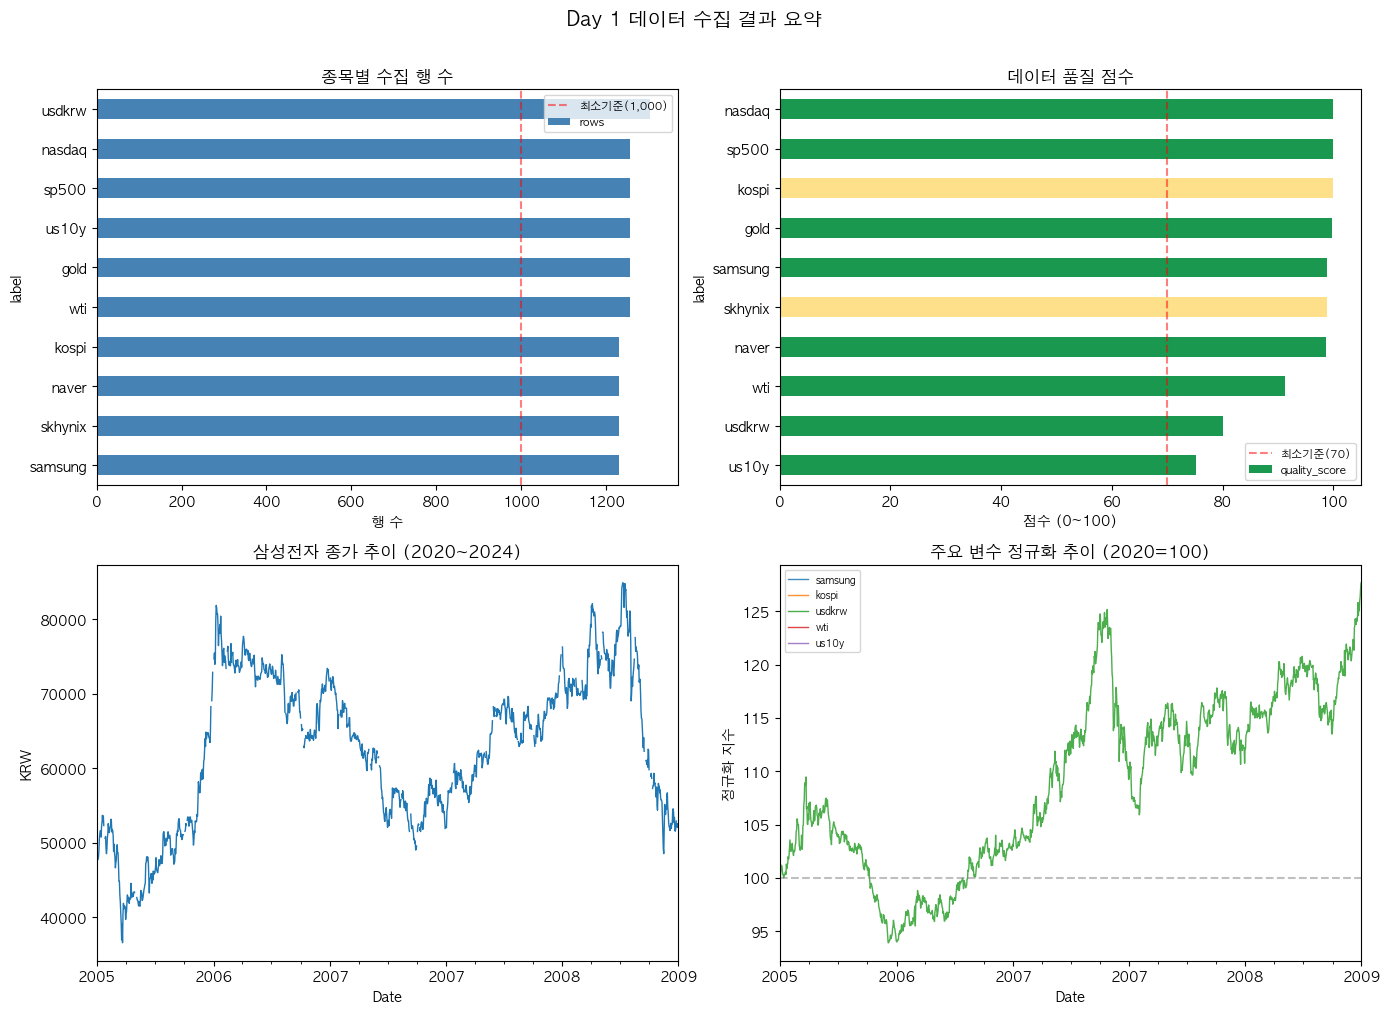

시각화 저장 완료


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Day 1 데이터 수집 결과 요약', fontsize=14, fontweight='bold', y=1.01)

# ── (1) 종목별 데이터 행 수 ────────────────────────────────
ax = axes[0, 0]
quality_report['rows'].sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('종목별 수집 행 수')
ax.set_xlabel('행 수')
ax.axvline(1000, color='red', linestyle='--', alpha=0.5, label='최소기준(1,000)')
ax.legend(fontsize=8)

# ── (2) 데이터 품질 점수 ──────────────────────────────────
ax = axes[0, 1]
colors = ['#d73027' if s < 70 else '#fee08b' if s < 85 else '#1a9850'
          for s in quality_report['quality_score']]
quality_report['quality_score'].sort_values().plot(kind='barh', ax=ax, color=colors)
ax.set_title('데이터 품질 점수')
ax.set_xlabel('점수 (0~100)')
ax.axvline(70, color='red', linestyle='--', alpha=0.5, label='최소기준(70)')
ax.set_xlim(0, 105)
ax.legend(fontsize=8)

# ── (3) 삼성전자 주가 추이 ────────────────────────────────
ax = axes[1, 0]
if 'samsung' in master_df.columns:
    master_df['samsung'].plot(ax=ax, color='#1f77b4', linewidth=1)
    ax.set_title('삼성전자 종가 추이 (2020~2024)')
    ax.set_ylabel('KRW')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# ── (4) 주요 외부 변수 정규화 추이 ───────────────────────
ax = axes[1, 1]
cols_to_plot = ['samsung', 'kospi', 'usdkrw', 'wti', 'us10y']
available = [c for c in cols_to_plot if c in master_df.columns]
normalized = master_df[available].div(master_df[available].iloc[0]) * 100
normalized.plot(ax=ax, linewidth=1, alpha=0.85)
ax.set_title('주요 변수 정규화 추이 (2020=100)')
ax.set_ylabel('정규화 지수')
ax.legend(fontsize=7, loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.axhline(100, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
fig.savefig(PROCESSED_DATA_DIR / 'day1_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('시각화 저장 완료')

## 9. Day 1 완료 체크리스트

| 항목 | 상태 |
|------|------|
| yfinance로 10개 종목/지수 수집 | ✅ |
| 원본 데이터 CSV 저장 (data/raw/) | ✅ |
| 데이터 품질 검사 (결측률·이상치·거래량) | ✅ |
| 결측치 처리 (ffill, 최대 5일) | ✅ |
| 이상치 처리 (30% 초과 대체, 20~30% 플래그) | ✅ |
| 정제 데이터 저장 (data/processed/) | ✅ |
| 데이터 품질 기준 JSON 문서화 | ✅ |
| 수집 결과 시각화 | ✅ |

**다음 단계 (Day 2):** EDA 및 상관관계 분석, 이벤트 전후 주가 반응 분석